# seaborn examples

In [1]:
import seaborn as sns

In [2]:
# Fix plot styles that VSCode broke
sns.set_theme(rc={'figure.figsize':(9, 4)})

## sea ice

In [3]:
seaice = sns.load_dataset('seaice')
print(f"{len(seaice)} rows loaded")

# Force column names to lowercase
seaice.columns = [x.lower() for x in seaice.columns]

# Show types
print("dataset type:")
print(type(seaice))
print("column types:")
print(seaice.dtypes, sep="\n")

# Show a few values
seaice.head()

13175 rows loaded
dataset type:
<class 'pandas.DataFrame'>
column types:
date      datetime64[us]
extent           float64
dtype: object


,date,extent
0,1980-01-01,14.200
1,1980-01-03,14.302
2,1980-01-05,14.414
3,1980-01-07,14.518
4,1980-01-09,14.594


<Axes: xlabel='date'>

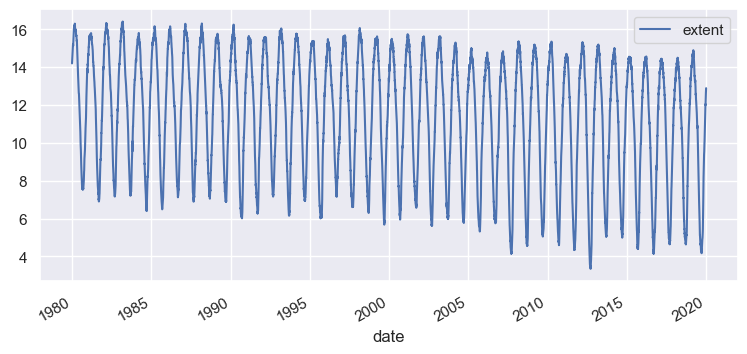

In [4]:
seaice.plot.line(x='date', y='extent')

Text(0.5, 1.0, 'sea ice')

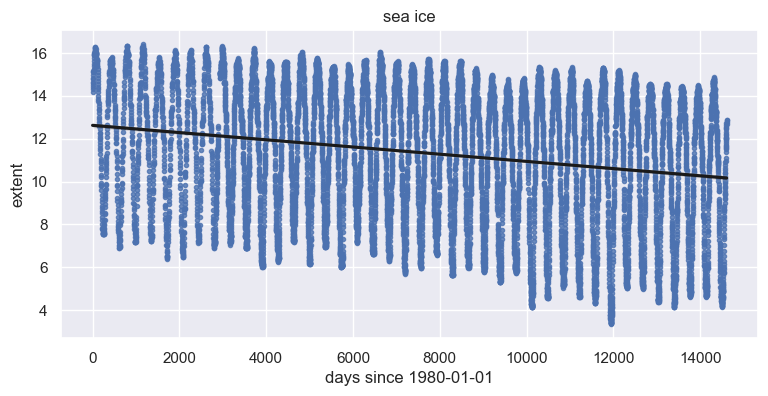

In [5]:
# Seaborn expects the x-axis to be a number, not a datetime.
# Create a new column: days since the first day in the dataset.
first_day = seaice['date'].min()
seaice['days'] = (seaice['date'] - first_day).dt.days

# Show a scatterplot with a linear regression line
axes = sns.regplot(
    seaice,
    x = "days",
    y = "extent",
    marker = '.',
    line_kws = {'color': 'k'},
)
axes.set_xlabel(f"days since {first_day.date()}")
axes.set_title('sea ice')